# Sampling figures (linear equations and parenthesized arithmetic)

Publication-oriented plots: **linear** metrics match the previous `test.ipynb` workflow; **parenthesis** metrics are read from `runs/parenthesis/stage1-depth8-100k/grid_search.jsonl` (output of `grid_search_samplers.py`).

In [1]:
"""Global style: NeurIPS/ICML-friendly defaults (vector PDF + 300 dpi raster)."""
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# Okabe–Ito colorblind-safe palette
SAMPLER_STYLES = {
    "euler": {"color": "#0072B2", "marker": "o", "ls": "-"},
    "staggered": {"color": "#E69F00", "marker": "s", "ls": "-"},
    "split": {"color": "#009E73", "marker": "^", "ls": "-"},
}

METHOD_LABELS = {"euler": "Euler", "staggered": "Staggered", "split": "Split"}
NFE_PER_STEP = {"euler": 1, "staggered": 2, "split": 3}


def configure_matplotlib():
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "font.size": 10.5,
            "axes.labelsize": 11,
            "axes.titlesize": 11.5,
            "axes.titleweight": "medium",
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
            "legend.fontsize": 9.5,
            "legend.title_fontsize": 10,
            "axes.linewidth": 0.9,
            "grid.linewidth": 0.6,
            "grid.alpha": 0.35,
            "lines.linewidth": 2.0,
            "lines.markersize": 6.5,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial", "sans-serif"],
            "mathtext.fontset": "dejavusans",
        }
    )
    mpl.rcParams["pdf.fonttype"] = 42
    mpl.rcParams["ps.fonttype"] = 42


configure_matplotlib()


def _fraction_ylim(lows: list, highs: list) -> tuple[float, float]:
    """Tight y-limits for [0,1] fractions; pads ~14% of span (min 0.01)."""
    arr_l = np.asarray([x for x in lows if np.isfinite(x)], dtype=float)
    arr_h = np.asarray([x for x in highs if np.isfinite(x)], dtype=float)
    if arr_l.size == 0 or arr_h.size == 0:
        return 0.0, 1.0
    dmin, dmax = float(arr_l.min()), float(arr_h.max())
    span = dmax - dmin
    pad = max(span * 0.15, 0.01)
    ymin = max(0.0, dmin - pad)
    ymax = min(1.0, dmax + pad)
    if ymax - ymin < 0.04:
        mid = 0.5 * (dmin + dmax)
        ymin = max(0.0, mid - 0.02)
        ymax = min(1.0, mid + 0.02)
    if ymax <= ymin:
        ymin, ymax = 0.0, 1.0
    return ymin, ymax


def plot_sampler_curves(
    df: pd.DataFrame,
    *,
    x_col: str,
    x_label: str,
    out_pdf: Path,
    out_png: Path | None = None,
    third_metric: str | None = None,
    third_panel_ylabel: str = "",
):
    """MAE + validity; optional third panel only if ``third_metric`` is set (e.g. ``1-KS`` for L=8)."""
    df = df.sort_values([x_col, "method"]).copy()
    if df.empty:
        print(f"No rows to plot → {out_pdf}")
        return

    panels = [("MAE", "Mean absolute error"), ("valid", "Validity")]
    if third_metric and third_metric in df.columns and third_panel_ylabel:
        panels.append((third_metric, third_panel_ylabel))

    ncols = len(panels)
    fig_w = 4.1 * ncols
    fig, axes = plt.subplots(1, ncols, figsize=(fig_w, 3.35), sharex=False, sharey=False)
    if ncols == 1:
        axes = [axes]

    y_zoom_axes: list[tuple] = []

    def _sampler_panel_title(idx: int, metric: str, y_label: str) -> str:
        letter = f"({chr(ord('a') + idx)}) "
        if metric == "MAE":
            return letter + "Mean absolute error"
        if metric == "valid":
            return letter + "Validity"
        if metric == "1-KS":
            return letter + r"Length ($1-\mathrm{KS}$) vs ground truth"
        return letter + y_label

    for idx, (ax, (metric, y_label)) in enumerate(zip(axes, panels)):
        lows: list = []
        highs: list = []
        for method in sorted(df["method"].unique()):
            sub = df[df["method"] == method].sort_values(x_col)
            sty = SAMPLER_STYLES.get(method, {"color": "#333333", "marker": "o", "ls": "-"})
            yerr = sub[f"{metric}_std"] if f"{metric}_std" in sub.columns else None
            label = METHOD_LABELS.get(method, method)
            y = sub[metric].to_numpy(dtype=float)
            ax.errorbar(
                sub[x_col],
                y,
                yerr=yerr,
                label=label,
                color=sty["color"],
                marker=sty["marker"],
                linestyle=sty["ls"],
                capsize=3.2,
                elinewidth=1.0,
            )
            if metric in ("valid", "accuracy", "1-KS"):
                if yerr is not None:
                    e = np.asarray(yerr.to_numpy(dtype=float), dtype=float)
                    mask = np.isfinite(y) & np.isfinite(e)
                    if mask.any():
                        lows.extend((y[mask] - e[mask]).tolist())
                        highs.extend((y[mask] + e[mask]).tolist())
                    lows.extend(y[np.isfinite(y)].tolist())
                    highs.extend(y[np.isfinite(y)].tolist())
                else:
                    lows.extend(y[np.isfinite(y)].tolist())
                    highs.extend(y[np.isfinite(y)].tolist())
        if metric in ("valid", "accuracy", "1-KS") and not lows:
            y_all = df[metric].to_numpy(dtype=float)
            y_all = y_all[np.isfinite(y_all)]
            if y_all.size:
                lows = y_all.tolist()
                highs = y_all.tolist()
        ax.set_xlabel(x_label)
        if metric == "valid" or metric == "accuracy":
            ax.set_ylabel("Fraction")
            ymin, ymax = _fraction_ylim(lows, highs)
            ax.set_autoscaley_on(False)
            ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
            ax.set_ylim(ymin, ymax)
            y_zoom_axes.append((ax, ymin, ymax))
        elif metric == "1-KS":
            ax.set_ylabel("$1 - \\mathrm{KS}$")
            ymin, ymax = _fraction_ylim(lows, highs)
            ax.set_autoscaley_on(False)
            ax.set_ylim(ymin, ymax)
            y_zoom_axes.append((ax, ymin, ymax))
        else:
            ax.set_ylabel(y_label)
        ax.set_title(_sampler_panel_title(idx, metric, y_label))
        ax.grid(True, axis="y", linestyle="--")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].legend(frameon=False, title="Sampler", loc="best")
    fig.tight_layout(w_pad=1.2)
    for ax, ymin, ymax in y_zoom_axes:
        ax.set_ylim(ymin, ymax)
    fig.savefig(out_pdf)
    if out_png is not None:
        fig.savefig(out_png)
    plt.show()


def load_jsonl(path: Path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


print("Style + helpers ready.")


Style + helpers ready.


## Linear equations (ours vs branching flows vs ground truth)

Per-$L$ histograms and trend curves, as before. Parsing uses `evaluate_equations_parenthesis.parse_equation`, which is valid for these additive linear chains (no `*`).

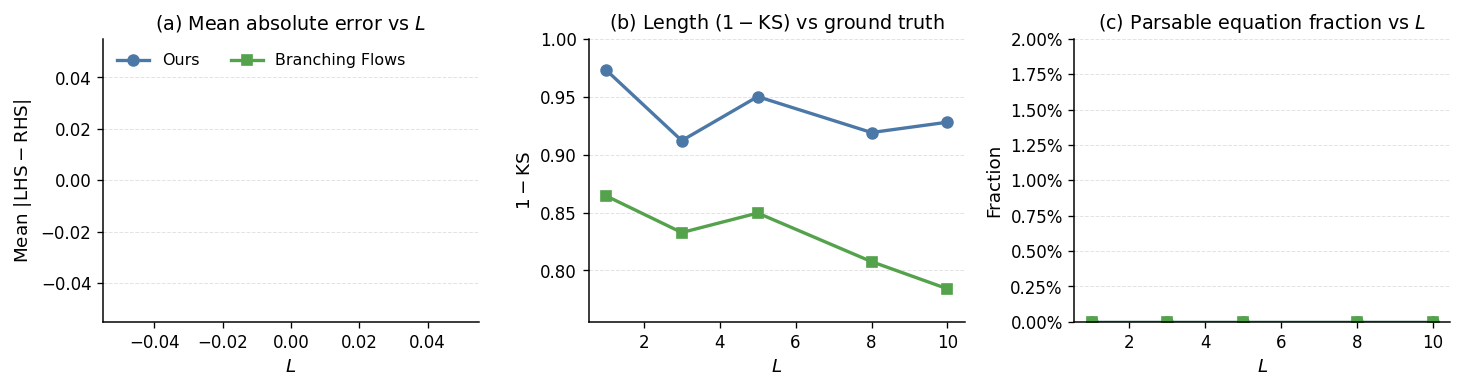


Ours
{'L': 1, 'n_samples': 1000, 'length_ks_vs_gt': 0.026740000000000097, 'mean_abs_error': nan, 'median_abs_error': nan, 'valid_abs_error_frac': 0.0}
{'L': 3, 'n_samples': 1000, 'length_ks_vs_gt': 0.08792, 'mean_abs_error': nan, 'median_abs_error': nan, 'valid_abs_error_frac': 0.0}
{'L': 5, 'n_samples': 1000, 'length_ks_vs_gt': 0.049919999999999964, 'mean_abs_error': nan, 'median_abs_error': nan, 'valid_abs_error_frac': 0.0}
{'L': 8, 'n_samples': 1000, 'length_ks_vs_gt': 0.08092000000000005, 'mean_abs_error': nan, 'median_abs_error': nan, 'valid_abs_error_frac': 0.0}
{'L': 10, 'n_samples': 1000, 'length_ks_vs_gt': 0.07199999999999995, 'mean_abs_error': nan, 'median_abs_error': nan, 'valid_abs_error_frac': 0.0}

Branching Flows
{'L': 1, 'n_samples': 49410, 'length_ks_vs_gt': 0.13552626998583284, 'mean_abs_error': nan, 'median_abs_error': nan, 'valid_abs_error_frac': 0.0}
{'L': 3, 'n_samples': 46773, 'length_ks_vs_gt': 0.16727303144976802, 'mean_abs_error': nan, 'median_abs_error': nan

In [2]:
import matplotlib as mpl
from evaluate_equations_parenthesis import (
    count_equation_symbols,
    parse_equation as parse_equation_linear,
)

L_VALUES = [1, 3, 5, 8, 10]

branching_flow_files = [f"branching_flows_samples/equations_l{i}_gen.jsonl" for i in L_VALUES]
our_files = [f"samples_toy-fresh/equations_l{i}/samples.jsonl" for i in L_VALUES]
data_files = [f"data/equations_l{i}.jsonl" for i in L_VALUES]


def extract_l_from_path(path):
    text = str(path)
    m = re.search(r"equations_l(\d+)", text)
    if m:
        return int(m.group(1))
    m = re.search(r"/l(\d+)/", text)
    if m:
        return int(m.group(1))
    raise ValueError(f"Could not infer L from path: {path}")


def equation_length(sample):
    symbols = sample.get("symbols", [])
    if symbols:
        return count_equation_symbols(symbols)
    if "length" in sample:
        return int(sample["length"])
    return len(sample.get("numbers", []))


def equation_abs_error(sample):
    symbols = sample.get("symbols", [])
    positions = sample.get("positions", sample.get("numbers", []))
    if not symbols or not positions:
        return None
    try:
        left_value, right_value = parse_equation_linear(
            symbols,
            positions,
            ignore_trailing_ops=True,
        )
    except Exception:
        return None
    diff = abs(left_value - right_value)
    if diff < 1e-10:
        return 0.0
    return diff


def collect_metrics_by_l(file_paths):
    out = {}
    for path in file_paths:
        l_value = extract_l_from_path(path)
        samples = load_jsonl(Path(path))
        lengths = [equation_length(s) for s in samples]
        abs_errors = []
        for s in samples:
            err = equation_abs_error(s)
            if err is not None:
                abs_errors.append(err)

        out[l_value] = {
            "path": str(Path(path)),
            "n_samples": len(samples),
            "lengths": np.asarray(lengths, dtype=float),
            "abs_errors": np.asarray(abs_errors, dtype=float),
        }
    return out


def ks_2sample_statistic(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size == 0 or y.size == 0:
        return np.nan
    x = np.sort(x)
    y = np.sort(y)
    all_values = np.unique(np.concatenate([x, y]))
    cdf_x = np.searchsorted(x, all_values, side="right") / x.size
    cdf_y = np.searchsorted(y, all_values, side="right") / y.size
    return float(np.max(np.abs(cdf_x - cdf_y)))


def summarize_method(metrics_by_l, gt_metrics_by_l=None):
    rows = []
    for l_value in sorted(metrics_by_l.keys()):
        row = metrics_by_l[l_value]
        lengths = row["lengths"]
        abs_errors = row["abs_errors"]

        length_ks_vs_gt = np.nan
        if gt_metrics_by_l is not None and l_value in gt_metrics_by_l:
            gt_lengths = gt_metrics_by_l[l_value]["lengths"]
            length_ks_vs_gt = ks_2sample_statistic(lengths, gt_lengths)

        rows.append(
            {
                "L": l_value,
                "n_samples": int(row["n_samples"]),
                "length_ks_vs_gt": length_ks_vs_gt,
                "mean_abs_error": float(np.mean(abs_errors)) if abs_errors.size else np.nan,
                "median_abs_error": float(np.median(abs_errors)) if abs_errors.size else np.nan,
                "valid_abs_error_frac": float(abs_errors.size / row["n_samples"]) if row["n_samples"] else np.nan,
            }
        )
    return rows


LINEAR_COLORS = {
    "Ours": "#4C78A8",
    "Branching Flows": "#54A24B",
    "Ground Truth": "#F58518",
}


def plot_comparison_for_l(all_metrics, l_value, bins_abs=20):
    fig, axes = plt.subplots(ncols=2, figsize=(9.2, 3.35))
    line_style = {"Ours": "-", "Branching Flows": "-", "Ground Truth": "-"}

    ax = axes[0]
    abs_methods = ["Ours", "Branching Flows"]
    max_diff_candidates = []
    for method_name in abs_methods:
        errors = all_metrics[method_name][l_value]["abs_errors"]
        if errors.size:
            max_diff_candidates.append(float(np.quantile(errors, 0.99)))
    max_diff = max(max_diff_candidates) if max_diff_candidates else 1.0
    max_diff = max(max_diff, 1e-6)

    for method_name in abs_methods:
        errors = all_metrics[method_name][l_value]["abs_errors"]
        if errors.size == 0:
            continue
        ax.hist(
            errors,
            bins=bins_abs,
            range=(0, max_diff),
            density=True,
            histtype="step",
            color=LINEAR_COLORS[method_name],
            linewidth=2.0,
            linestyle=line_style[method_name],
            label=method_name,
        )
    if not max_diff_candidates:
        ax.text(0.5, 0.5, "No valid equations parsed", ha="center", va="center", transform=ax.transAxes)
    ax.set_xlabel("$|\\mathrm{LHS}-\\mathrm{RHS}|$")
    ax.set_ylabel("Density")
    ax.set_title(f"(a) Mean absolute error ($L={l_value}$)")
    ax.grid(True, axis="y", linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax = axes[1]
    max_len = 1
    for method_name in LINEAR_COLORS:
        lengths = all_metrics[method_name][l_value]["lengths"]
        if lengths.size:
            max_len = max(max_len, int(np.max(lengths)))
    bins = np.arange(1, max_len + 2) - 0.5
    for method_name in LINEAR_COLORS:
        lengths = all_metrics[method_name][l_value]["lengths"]
        if lengths.size == 0:
            continue
        ax.hist(
            lengths,
            bins=bins,
            density=True,
            histtype="step",
            color=LINEAR_COLORS[method_name],
            linewidth=2.0,
            linestyle=line_style[method_name],
            label=method_name,
        )
    bf_len = all_metrics["Branching Flows"][l_value]["lengths"]
    gt_len = all_metrics["Ground Truth"][l_value]["lengths"]
    if bf_len.size and gt_len.size and np.array_equal(bf_len, gt_len):
        ax.text(0.98, 0.95, "BF and GT overlap", ha="right", va="top", fontsize=8.5, transform=ax.transAxes)
    ax.set_xlabel("Sequence length")
    ax.set_title(f"(b) Length distribution ($L={l_value}$)")
    ax.grid(True, axis="y", linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    handles, labels = axes[1].get_legend_handles_labels()
    axes[0].legend(handles, labels, frameon=False, loc="upper left", ncol=3)
    fig.tight_layout(w_pad=1.2)
    fig.savefig(PLOTS_DIR / f"linear_l{l_value}.pdf")
    fig.savefig(PLOTS_DIR / f"linear_l{l_value}.png")
    plt.show()


def plot_trends_vs_l(all_metrics):
    fig, axes = plt.subplots(ncols=3, figsize=(12.3, 3.35))
    styles = {"Ours": (LINEAR_COLORS["Ours"], "o"), "Branching Flows": (LINEAR_COLORS["Branching Flows"], "s")}
    gt_metrics = all_metrics["Ground Truth"]

    ks_vals: list[float] = []
    vf_vals: list[float] = []

    for method_name, (color, marker) in styles.items():
        summary = summarize_method(all_metrics[method_name], gt_metrics_by_l=gt_metrics)
        ls = [r["L"] for r in summary]
        mean_abs = [r["mean_abs_error"] for r in summary]
        length_ks = [r["length_ks_vs_gt"] for r in summary]
        length_one_minus_ks = [1.0 - v if np.isfinite(v) else np.nan for v in length_ks]
        valid_frac = [r["valid_abs_error_frac"] for r in summary]
        axes[0].plot(ls, mean_abs, marker=marker, color=color, label=method_name)
        axes[1].plot(ls, length_one_minus_ks, marker=marker, color=color, label=method_name)
        axes[2].plot(ls, valid_frac, marker=marker, color=color, label=method_name)
        ks_vals.extend(float(x) for x in length_one_minus_ks if np.isfinite(x))
        vf_vals.extend(float(x) for x in valid_frac if np.isfinite(x))

    ylim_ks = _fraction_ylim(ks_vals, ks_vals)
    ylim_vf = _fraction_ylim(vf_vals, vf_vals)

    axes[0].set_title("(a) Mean absolute error vs $L$")
    axes[0].set_xlabel("$L$")
    axes[0].set_ylabel("Mean $|\\mathrm{LHS}-\\mathrm{RHS}|$")

    axes[1].set_title("(b) Length ($1 - \\mathrm{KS}$) vs ground truth")
    axes[1].set_xlabel("$L$")
    axes[1].set_ylabel("$1 - \\mathrm{KS}$")
    axes[1].set_autoscaley_on(False)
    axes[1].set_ylim(*ylim_ks)

    axes[2].set_title("(c) Parsable equation fraction vs $L$")
    axes[2].set_xlabel("$L$")
    axes[2].set_ylabel("Fraction")
    axes[2].set_autoscaley_on(False)
    axes[2].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
    axes[2].set_ylim(*ylim_vf)

    for ax in axes:
        ax.grid(True, axis="y", linestyle="--")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, frameon=False, loc="upper left", ncol=2)
    fig.tight_layout(w_pad=1.2)
    axes[1].set_ylim(*ylim_ks)
    axes[2].set_ylim(*ylim_vf)
    fig.savefig(PLOTS_DIR / "linear_trends_vs_L.pdf")
    # fig.savefig(PLOTS_DIR / "linear_trends_vs_L.png")
    plt.show()


all_metrics = {
    "Ours": collect_metrics_by_l(our_files),
    "Branching Flows": collect_metrics_by_l(branching_flow_files),
    "Ground Truth": collect_metrics_by_l(data_files),
}

# for l_value in L_VALUES:
#     plot_comparison_for_l(all_metrics, l_value)

plot_trends_vs_l(all_metrics)

gt_metrics = all_metrics["Ground Truth"]
for method_name in ["Ours", "Branching Flows", "Ground Truth"]:
    print(f"\n{method_name}")
    for row in summarize_method(all_metrics[method_name], gt_metrics_by_l=gt_metrics):
        print(row)


## Toy model at $L=8$: MAE, validity, and length $1 - \mathrm{KS}$ vs. GT

Reads `samples_toy/equations_l8_*` with multi-seed aggregation when present. The third panel is $1 - \mathrm{KS}$ between **sequence lengths** (all samples) and ground-truth lengths.


In [3]:
import statistics

from scipy.stats import ks_2samp

SAMPLES_ROOT = Path("samples-full/samples_toy")
L8 = 8
DELTA_ACC = 1.0
MAX_SAMPLES_L8: int | None = 10000


def evaluate_samples_file(
    path: Path,
    gt_lengths: np.ndarray | None = None,
    delta_acc: float = DELTA_ACC,
    max_samples: int | None = None,
):
    samples = load_jsonl(path)
    if max_samples is not None:
        samples = samples[:max_samples]
    total = len(samples)
    errors = [equation_abs_error(s) for s in samples]
    valid_errors = [e for e in errors if e is not None]
    valid_frac = len(valid_errors) / total if total else 0.0
    mae = float(np.mean(valid_errors)) if valid_errors else np.nan
    correct_acc = sum(e < delta_acc for e in valid_errors)
    accuracy = (correct_acc + (total - len(valid_errors)) * 0.0) / total if total else 0.0
    accuracy_on_valid_only = correct_acc / len(valid_errors) if valid_errors else np.nan

    def _length(s):
        if "length" in s:
            return int(s["length"])
        if s.get("symbols"):
            return count_equation_symbols(s["symbols"])
        return len(s.get("positions", s.get("numbers", [])))

    one_minus_ks = np.nan
    if gt_lengths is not None and gt_lengths.size > 0:
        sample_lengths = np.array([_length(s) for s in samples])
        if sample_lengths.size > 0:
            ks_stat, _ = ks_2samp(sample_lengths, gt_lengths)
            one_minus_ks = 1.0 - ks_stat

    return {
        "MAE": mae,
        "valid": valid_frac,
        "accuracy": accuracy,
        "accuracy_valid": accuracy_on_valid_only,
        "1-KS": one_minus_ks,
    }


def collect_results_for_length(length_value: int, max_samples: int | None = None):
    def _sample_length(s):
        if "length" in s:
            return int(s["length"])
        if s.get("symbols"):
            return count_equation_symbols(s["symbols"])
        return len(s.get("positions", s.get("numbers", [])))

    gt_path = Path(f"data/equations_l{length_value}.jsonl")
    gt_lengths = np.array([], dtype=float)
    if gt_path.exists():
        gt_samples = load_jsonl(gt_path)
        gt_lengths = np.array([_sample_length(s) for s in gt_samples])

    method_map = {"euler": ["euler"], "staggered": ["staggered"], "split": ["2ndorder"]}
    out = {m: [] for m in method_map}

    for method_label, method_keys in method_map.items():
        for method_key in method_keys:
            seed_files = sorted(SAMPLES_ROOT.glob(f"equations_l{length_value}_{method_key}_*/seed_*/samples.jsonl"))
            flat_files = sorted(SAMPLES_ROOT.glob(f"equations_l{length_value}_{method_key}_*/samples.jsonl"))
            files = seed_files if seed_files else flat_files

            by_steps: dict[int, list] = {}
            for path in files:
                if "seed_" in str(path):
                    base_name = path.parent.parent.name
                else:
                    base_name = path.parent.name
                m = re.search(r"_(\d+)$", base_name)
                if not m:
                    continue
                steps = int(m.group(1))
                metrics = evaluate_samples_file(path, gt_lengths=gt_lengths, max_samples=max_samples)
                by_steps.setdefault(steps, []).append(metrics)

            for steps, seed_metrics in by_steps.items():
                agg = {"steps": steps}
                for key in ["MAE", "valid", "accuracy", "1-KS"]:
                    vals = [m[key] for m in seed_metrics]
                    agg[key] = statistics.fmean(vals)
                    agg[f"{key}_std"] = statistics.stdev(vals) if len(vals) > 1 else 0.0
                out[method_label].append(agg)

        uniq = {row["steps"]: row for row in out[method_label]}
        out[method_label] = sorted(uniq.values(), key=lambda x: x["steps"])

    out = {k: v for k, v in out.items() if v}
    if not out:
        return out

    def nfe_for(method_label: str, steps: int) -> int:
        return steps * NFE_PER_STEP.get(method_label, 1)

    def nfe_bin(nfe: int) -> int:
        return round(nfe / 25) * 25

    nfe_sets = []
    for method_label, entries in out.items():
        nfe_sets.append({nfe_bin(nfe_for(method_label, r["steps"])) for r in entries})
    shared = set.intersection(*nfe_sets)

    for method_label in out:
        out[method_label] = sorted(
            [r for r in out[method_label] if nfe_bin(nfe_for(method_label, r["steps"])) in shared],
            key=lambda x: x["steps"],
            reverse=True,
        )
    return out


def sampler_dict_to_df(results_dict):
    rows = []
    for method, entries in results_dict.items():
        nfe_ps = NFE_PER_STEP.get(method, 1)
        for e in entries:
            rows.append({"method": method, **e, "nfe": e["steps"] * nfe_ps})
    return pd.DataFrame(rows)


results_l8 = collect_results_for_length(L8, max_samples=MAX_SAMPLES_L8)
df_l8 = sampler_dict_to_df(results_l8)
print(f"L={L8} sampler grid (max_samples={MAX_SAMPLES_L8}):", len(df_l8), "rows")

if not df_l8.empty:
    plot_sampler_curves(
        df_l8,
        x_col="steps",
        x_label="Integration steps",
        out_pdf=PLOTS_DIR / "toy_l8_samplers_steps.pdf",
        # out_png=PLOTS_DIR / "toy_l8_samplers_steps.png",
        third_metric="1-KS",
        third_panel_ylabel="Length vs. GT ($1 - \\mathrm{KS}$)",
    )
    plot_sampler_curves(
        df_l8.sort_values("nfe"),
        x_col="nfe",
        x_label="NFE (per sampler)",
        out_pdf=PLOTS_DIR / "toy_l8_samplers_nfe.pdf",
        # out_png=PLOTS_DIR / "toy_l8_samplers_nfe.png",
        third_metric="1-KS",
        third_panel_ylabel="Length vs. GT ($1 - \\mathrm{KS}$)",
    )
    plot_sampler_curves(
        df_l8,
        x_col="steps",
        x_label="Integration steps",
        out_pdf=PLOTS_DIR / "toy_l8_samplers_steps_2p.pdf",
        # out_png=PLOTS_DIR / "toy_l8_samplers_steps_2p.png",
    )
    plot_sampler_curves(
        df_l8.sort_values("nfe"),
        x_col="nfe",
        x_label="NFE (per sampler)",
        out_pdf=PLOTS_DIR / "toy_l8_samplers_nfe_2p.pdf",
        # out_png=PLOTS_DIR / "toy_l8_samplers_nfe_2p.png",
    )
else:
    print("No samples under samples_toy/ — skip L=8 sampler plots.")


AttributeError: 'float' object has no attribute 'numerator'

## Parenthesis: grid search (`grid_search.jsonl`)

Same line/errorbar aesthetic as the $L=8$ toy panel. Adjust `GRID_SEARCH_JSONL` if your run directory differs.

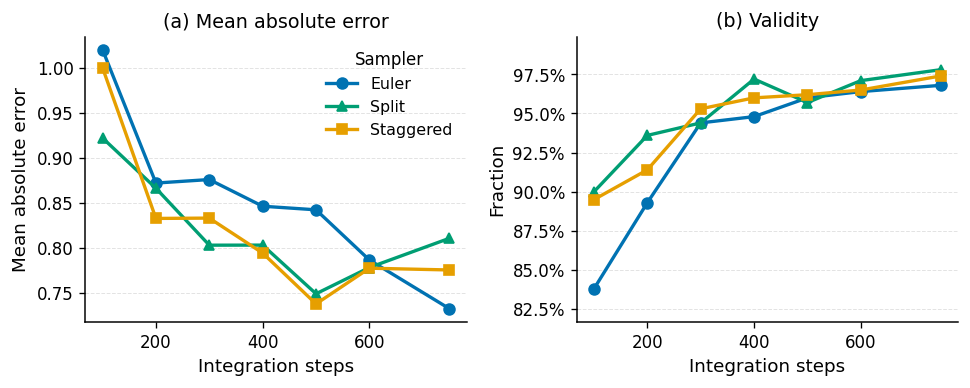

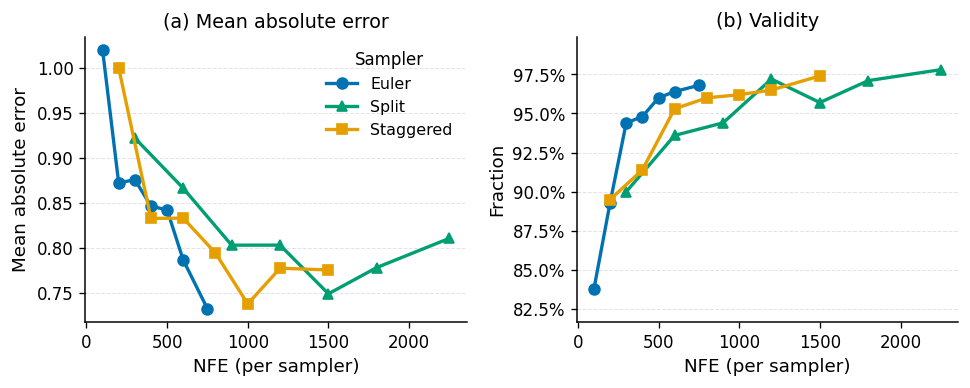

In [ ]:
GRID_SEARCH_JSONL = Path("runs/parenthesis/stage1-depth8-100k/grid_search.jsonl")


def load_parenthesis_grid(path: Path) -> pd.DataFrame:
    rows = []
    if not path.exists():
        print(f"Missing {path} — generate with grid_search_samplers.py")
        return pd.DataFrame()
    for r in load_jsonl(path):
        n = int(r["eval_samples"])
        rows.append(
            {
                "method": r["sampler"],
                "steps": int(r["steps"]),
                "nfe": int(r["steps"]) * NFE_PER_STEP[r["sampler"]],
                "MAE": float(r["mean_abs_error"]),
                "valid": float(r["valid"]) / n,
                # Match toy panel: fraction of all samples that parse and meet threshold |Δ| < 0.5
                "accuracy": float(r["correct"]) / n,
                "accuracy_cond_valid": float(r["accuracy"]),
            }
        )
    return pd.DataFrame(rows)


df_paren = load_parenthesis_grid(GRID_SEARCH_JSONL)

if not df_paren.empty:
    plot_sampler_curves(
        df_paren,
        x_col="steps",
        x_label="Integration steps",
        out_pdf=PLOTS_DIR / "parenthesis_grid_samplers_steps.pdf",
        # out_png=PLOTS_DIR / "parenthesis_grid_samplers_steps.png",
    )
    plot_sampler_curves(
        df_paren.sort_values("nfe"),
        x_col="nfe",
        x_label="NFE (per sampler)",
        out_pdf=PLOTS_DIR / "parenthesis_grid_samplers_nfe.pdf",
        # out_png=PLOTS_DIR / "parenthesis_grid_samplers_nfe.png",
    )
    df_paren.sort_values(["method", "steps"]).reset_index(drop=True)
else:
    print("No parenthesis grid to plot.")


## Dataset overview: snapshot + 2x2 ours-vs-baseline grid

Stylized companion to the dataset overview figure. Layout:

- **Left:** dataset syntax snapshot (token chips + simple/parenthesized examples).
- **Top right (with parentheses):** our method's valid samples vs. a single big "✗ — Baseline cannot generate parenthesized equations" panel.
- **Bottom right (without parentheses):** our method's valid samples vs. baseline failure modes (duplicated `=`, near-duplicate numbers).

Outputs: `figures/dataset_overview_2x2.{png,pdf}`.

In [ ]:
"""Dataset overview figure: snapshot + 2x2 ours-vs-baseline grid.

Layout:
- Left panel A: dataset syntax snapshot (token chips + simple/parenthesized examples).
- Right 2x2 grid:
    Top row    = WITH parentheses    (Ours valid samples | Baseline cannot produce parens, big X)
    Bottom row = WITHOUT parentheses (Ours valid samples | Baseline failure modes with highlights)

Reads:
- Ours: runs/parenthesis/stage1-depth8-train160k/itr_155000/samples.jsonl  (60% acc)
- Baseline: branching_flows_samples/equations_l5_gen.jsonl
"""

from pathlib import Path
import json
import random
import re
import ast

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.font_manager import FontProperties
from matplotlib.gridspec import GridSpec

from evaluate_equations_parenthesis import parse_equation as _parse_equation_parenthesis


CFG = {
    "seed": 15,
    "ours_target_correct": 3,
    "baseline_target_examples": 3,
    "sample_max_chars": 30,
    "max_chars_per_equation": 34,
    "figsize": (16.0, 5.6),
    "dpi": 400,
    "equation_fontsize": 11.4,
    "equation_fontfamily": "DejaVu Sans Mono",
    "title": "Equation Dataset at a Glance: Our Method vs Baseline",
    "quality_tolerance": 0.5,
    "close_number_delta": 0.50,
    "save_png": "figures/dataset_overview_2x2.png",
    "save_pdf": "figures/dataset_overview_2x2.pdf",
    "palette": {
        "figure_bg": "#f7f7fb",
        "card_bg": "#ffffff",
        "card_edge": "#d9d7f8",
        "title": "#1c1d2b",
        "subtitle": "#4b4e6d",
        "body": "#26273a",
        "muted": "#6a6d8f",
        "accent_real": "#5b8def",
        "accent_ours": "#18a999",
        "accent_base": "#e76f51",
        "ok": "#2a9d8f",
        "warn": "#e76f51",
        "box_close": "#F59E0B",
        "box_double_equal": "#e63946",
    },
    "ours_path": "runs/parenthesis/stage1-depth8-train160k/itr_155000/samples.jsonl",
    "baseline_path": "branching_flows_samples/equations_l5_gen.jsonl",
}


# ---------- shared helpers (mirrored from test.ipynb) ----------

def _format_number(value):
    try:
        x = float(value)
    except (TypeError, ValueError):
        return str(value)
    if abs(x - round(x)) < 1e-6:
        return str(int(round(x)))
    return f"{x:.2f}".rstrip("0").rstrip(".")


def _numbers_symbols_to_equation(numbers, symbols):
    if not isinstance(symbols, list) or not symbols:
        return ""
    if not isinstance(numbers, list):
        numbers = []
    out, n_idx = [], 0
    for tok in symbols:
        tok = str(tok)
        if tok in {"(", ")"}:
            out.append(tok)
            continue
        if n_idx < len(numbers):
            out.append(_format_number(numbers[n_idx]))
            n_idx += 1
        out.append(tok)
    return "".join(out).strip()


def _load_jsonl_records(path):
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def _clean_equation_display(eq):
    return eq.strip().rstrip(".")


def _fix_trailing_binop_before_close(s):
    changed = True
    while changed:
        changed = False
        i = 0
        while i < len(s):
            if s[i] != ")":
                i += 1
                continue
            depth = 1
            j = i - 1
            while j >= 0 and depth:
                if s[j] == ")":
                    depth += 1
                elif s[j] == "(":
                    depth -= 1
                if depth == 0:
                    break
                j -= 1
            if j < 0:
                i += 1
                continue
            inner = s[j + 1:i]
            if inner and inner[-1] in "+-" and "(" not in inner:
                op = inner[-1]
                core = inner[:-1]
                s = s[:j] + f"({core}){op}" + s[i + 1:]
                changed = True
                break
            i += 1
    return s


def _has_singleton_paren_wrapped_number(eq):
    for m in re.finditer(r"\(([^()]*)\)", eq):
        if re.fullmatch(r"-?\d+(?:\.\d+)?", m.group(1).strip()):
            return True
    return False


def _normalize_paren_display(s):
    s = _fix_trailing_binop_before_close(s)
    while "()" in s:
        s = s.replace("()", "")
    num_only = re.compile(r"\(\s*(-?\d+(?:\.\d+)?)\s*\)")
    while True:
        s2, n = num_only.subn(r"\1", s)
        if n == 0:
            break
        s = s2
    return s


def _truncate(text, n):
    return text if len(text) <= n else text[:n - 3] + "..."


def _safe_eval_arith(expr):
    node = ast.parse(expr, mode="eval")

    def _eval(n):
        if isinstance(n, ast.Expression):
            return _eval(n.body)
        if isinstance(n, ast.Constant) and isinstance(n.value, (int, float)):
            return float(n.value)
        if isinstance(n, ast.UnaryOp) and isinstance(n.op, (ast.UAdd, ast.USub)):
            v = _eval(n.operand)
            return v if isinstance(n.op, ast.UAdd) else -v
        if isinstance(n, ast.BinOp) and isinstance(n.op, (ast.Add, ast.Sub, ast.Mult)):
            l, r = _eval(n.left), _eval(n.right)
            if isinstance(n.op, ast.Add): return l + r
            if isinstance(n.op, ast.Sub): return l - r
            return l * r
        raise ValueError("unsupported")
    return _eval(node)


def _equation_error(eq):
    if "=" not in eq:
        return None
    clean = eq.strip().rstrip(".")
    left, right = clean.split("=", 1)
    if not left.strip() or not right.strip():
        return None
    try:
        return abs(_safe_eval_arith(left) - _safe_eval_arith(right))
    except Exception:
        return None


def _equation_abs_error_parenthesis(item):
    sym = item.get("symbols")
    pos = item.get("positions", item.get("numbers", []))
    if not sym or not pos:
        return None
    try:
        l, r = _parse_equation_parenthesis(list(sym), pos, ignore_trailing_ops=True)
    except Exception:
        return None
    return abs(float(l) - float(r))


def _has_double_equal(eq):
    return eq.count("=") >= 2 or "==" in eq


def _extract_numbers(eq):
    return [float(m.group()) for m in re.finditer(r"-?\d+(?:\.\d+)?", eq)]


def _has_long_close_sequence(eq, delta=0.20, min_run=3):
    nums = _extract_numbers(eq)
    if len(nums) < min_run:
        return False
    run = 1
    for i in range(len(nums) - 1):
        if abs(nums[i] - nums[i + 1]) <= delta:
            run += 1
            if run >= min_run:
                return True
        else:
            run = 1
    return False


def _is_correct_equation(eq, tol=0.25):
    clean = _clean_equation_display(eq)
    if clean.count("=") != 1: return False
    if clean.count("(") != clean.count(")"): return False
    if clean.endswith(("+", "-", "*", "=")): return False
    err = _equation_error(clean)
    return err is not None and err <= tol


def _detect_baseline_issues(eq):
    issues = []
    if "=" not in eq: issues.append("no_equal")
    if eq.count("(") != eq.count(")"): issues.append("unbalanced_paren")
    if eq.strip().endswith(("+", "-", "*", "=")): issues.append("incomplete_tail")
    if eq.count("=") >= 2: issues.append("double_equal")
    return issues


def _merge_spans(spans, gap=0):
    if not spans: return []
    s = sorted(spans)
    out = [list(s[0])]
    for a, b in s[1:]:
        if a <= out[-1][1] + gap: out[-1][1] = max(out[-1][1], b)
        else: out.append([a, b])
    return [(a, b) for a, b in out]


def _find_issue_spans(eq, close_number_delta=0.20):
    close_spans, deq_spans = [], []
    nums = list(re.finditer(r"-?\d+(?:\.\d+)?", eq))
    for i in range(len(nums) - 1):
        if abs(float(nums[i].group()) - float(nums[i + 1].group())) <= close_number_delta:
            close_spans.append((nums[i].start(), nums[i + 1].end()))
    for m in re.finditer(r"={2,}", eq):
        deq_spans.append(m.span())
    eqps = [i for i, c in enumerate(eq) if c == "="]
    if len(eqps) >= 2 and not deq_spans:
        deq_spans.append((eqps[0], eqps[-1] + 1))
    return {
        "close_numbers": _merge_spans(close_spans, gap=1),
        "double_equal": _merge_spans(deq_spans, gap=0),
    }


def _truncate_spans(spans, n):
    return [(s, min(e, n)) for s, e in spans if s < n]


# ---------- selection ----------

def _curate_ours(records, want_parens, n, max_chars, tol, rng):
    rows, seen = [], set()
    for item in records:
        sym = item.get("symbols", [])
        has_p = ("(" in sym) or (")" in sym)
        if has_p != want_parens:
            continue
        eq = _numbers_symbols_to_equation(item.get("numbers", []), sym)
        if not eq: continue
        clean = _clean_equation_display(eq)
        if "()" in clean or _has_singleton_paren_wrapped_number(clean):
            continue
        # for the "without parens" panel, drop any sample whose normalized form still has parens.
        disp = _normalize_paren_display(clean)
        if want_parens and "(" not in disp:
            continue
        if (not want_parens) and ("(" in disp or ")" in disp):
            continue
        if disp in seen: continue
        seen.add(disp)
        err = _equation_abs_error_parenthesis(item)
        rows.append((disp, err))
    rows = [r for r in rows if len(r[0]) <= max_chars]
    correct = [r for r in rows if r[1] is not None and r[1] <= tol]
    pool = correct if len(correct) >= n else correct + [r for r in rows if r not in correct]
    rng.shuffle(pool)
    pick = pool[:n]
    return [p[0] for p in pick], [p[1] for p in pick]


def _curate_baseline_failures(eqs, n, max_chars, tol, delta, rng):
    dedup = [e for e in dict.fromkeys(eqs) if len(_clean_equation_display(e)) <= max_chars]
    panel = []

    def pick_one(pred):
        for e in dedup:
            if e in panel: continue
            if pred(e):
                panel.append(e); return

    pick_one(lambda e: _has_double_equal(_clean_equation_display(e)))
    pick_one(lambda e: _has_long_close_sequence(_clean_equation_display(e), delta=delta, min_run=3))
    pick_one(lambda e: not _is_correct_equation(e, tol=tol))
    while len(panel) < n:
        for e in dedup:
            if e not in panel:
                panel.append(e); break
        else:
            break
    return panel[:n]


# ---------- drawing primitives ----------

def _add_card(ax, face, edge):
    ax.add_patch(FancyBboxPatch(
        (0.0, 0.0), 1.0, 1.0,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        transform=ax.transAxes, linewidth=1.4, edgecolor=edge, facecolor=face, zorder=0))


def _draw_panel_header(ax, title, accent, palette, subtitle=None):
    ax.text(0.04, 0.92, title, ha="left", va="center", fontsize=11.5,
            fontweight="bold", color=palette["title"])
    ax.plot([0.04, 0.96], [0.86, 0.86], lw=2.5, color=accent, solid_capstyle="round")
    if subtitle:
        ax.text(0.04, 0.81, subtitle, ha="left", va="center", fontsize=9.2,
                color=palette["muted"], style="italic")


def _draw_equation_list(ax, equations, palette, *, mode, cfg, quality_errors=None):
    """mode in {"ours", "baseline"}."""
    if not equations:
        ax.text(0.5, 0.5, "(no samples)", ha="center", va="center",
                fontsize=10, color=palette["muted"], transform=ax.transAxes)
        return

    n = len(equations)
    y_top, y_bot = 0.72, 0.18
    ys = [0.5 * (y_top + y_bot)] if n == 1 else [y_top - i * (y_top - y_bot) / (n - 1) for i in range(n)]

    text_x = 0.072
    fp = FontProperties(family=cfg["equation_fontfamily"], size=cfg["equation_fontsize"])
    ax.figure.canvas.draw()
    rend = ax.figure.canvas.get_renderer()

    def px2dx(px):
        p0 = ax.transAxes.inverted().transform((0, 0))
        p1 = ax.transAxes.inverted().transform((px, 0))
        return p1[0] - p0[0]

    def px2dy(px):
        p0 = ax.transAxes.inverted().transform((0, 0))
        p1 = ax.transAxes.inverted().transform((0, px))
        return p1[1] - p0[1]

    for i, eq in enumerate(equations):
        y = ys[i]
        clean = _clean_equation_display(eq)
        disp = _normalize_paren_display(clean)
        text = _truncate(disp, cfg["max_chars_per_equation"])

        if mode == "ours":
            err = quality_errors[i] if quality_errors and i < len(quality_errors) else _equation_error(clean)
            issue = (err is None or err > cfg["quality_tolerance"])
        else:
            issue = bool(_detect_baseline_issues(clean)) or not _is_correct_equation(clean, tol=cfg["quality_tolerance"])

        row_h = 0.16 if n <= 3 else 0.13
        face = "#FEF2F2" if issue else "#ECFDF5"
        edge = "#FECACA" if issue else "#A7F3D0"
        ax.add_patch(FancyBboxPatch(
            (0.04, y - row_h / 2), 0.92, row_h,
            boxstyle="round,pad=0.004,rounding_size=0.010",
            linewidth=0.9, edgecolor=edge, facecolor=face, zorder=1, transform=ax.transAxes))

        ax.text(text_x, y, text, ha="left", va="center",
                fontsize=cfg["equation_fontsize"], family=cfg["equation_fontfamily"],
                color=palette["body"], zorder=4)

        if mode == "baseline":
            spans = _find_issue_spans(clean, close_number_delta=cfg["close_number_delta"])
            cmap = {"close_numbers": palette["box_close"], "double_equal": palette["box_double_equal"]}
            _, th, _ = rend.get_text_width_height_descent(text, fp, ismath=False)
            box_h = px2dy(th) * 1.35
            for kind, sp in spans.items():
                for s, e in _truncate_spans(sp, len(text)):
                    if e <= s: continue
                    pre, seg = text[:s], text[s:e]
                    pw, _, _ = rend.get_text_width_height_descent(pre, fp, ismath=False)
                    sw, _, _ = rend.get_text_width_height_descent(seg, fp, ismath=False)
                    x = text_x + px2dx(pw)
                    w = max(px2dx(sw), px2dx(6.0))
                    ax.add_patch(FancyBboxPatch(
                        (x - 0.0022, y - box_h / 2), w + 0.0044, box_h,
                        boxstyle="round,pad=0.0022,rounding_size=0.0048",
                        linewidth=1.35, edgecolor=cmap.get(kind, palette["warn"]),
                        facecolor="none", zorder=2))

        mark = "✗" if issue else "✓"
        mc = palette["warn"] if issue else palette["ok"]
        ax.text(0.92, y, mark, ha="center", va="center",
                fontsize=13.0, color=mc, fontweight="bold", zorder=4)


def _draw_cannot_panel(ax, palette, cfg, message):
    """Big-X panel for: baseline cannot produce parenthesized equations."""
    ax.add_patch(FancyBboxPatch(
        (0.10, 0.20), 0.80, 0.62,
        boxstyle="round,pad=0.01,rounding_size=0.02",
        linewidth=1.2, edgecolor="#FECACA", facecolor="#FEF2F2",
        transform=ax.transAxes, zorder=1))
    ax.text(0.50, 0.62, "✗", ha="center", va="center",
            fontsize=64, color=palette["warn"], fontweight="bold",
            transform=ax.transAxes, zorder=3)
    ax.text(0.50, 0.34, message, ha="center", va="center",
            fontsize=10.6, color=palette["body"], style="italic",
            wrap=True, transform=ax.transAxes, zorder=3)


def _draw_snapshot(ax, palette, cfg):
    _add_card(ax, palette["card_bg"], palette["card_edge"])
    ax.text(0.04, 0.945, "A. Dataset Syntax Snapshot", ha="left", va="center",
            fontsize=12.5, fontweight="bold", color=palette["title"])
    ax.plot([0.04, 0.96], [0.905, 0.905], lw=3, color=palette["accent_real"], solid_capstyle="round")

    chips = [
        ("digits", "#E2E8F0", palette["body"]),
        ("+", "#DBF5EF", "#0F766E"),
        ("-", "#FEE4E2", "#9F1239"),
        ("(", "#EDE9FE", "#5B21B6"),
        (")", "#EDE9FE", "#5B21B6"),
        ("=", "#E0EAFF", "#1D4ED8"),
    ]
    chip_y = 0.82
    x = 0.05
    for label, face, tcolor in chips:
        w = 0.078 if len(label) <= 2 else 0.16
        ax.add_patch(FancyBboxPatch(
            (x, chip_y - 0.026), w, 0.052,
            boxstyle="round,pad=0.004,rounding_size=0.010",
            linewidth=0.8, edgecolor="#D1D5DB", facecolor=face, transform=ax.transAxes))
        ax.text(x + w / 2, chip_y, label, ha="center", va="center",
                fontsize=9.4, color=tcolor, fontweight="semibold")
        x += w + 0.014

    card_specs = [
        ("Simple", "1-2+3=3-1", 0.05, 0.55),
        ("Parenthesized", "(1-3)+4=4-(4-2)", 0.05, 0.34),
    ]
    for title, eq, x0, y0 in card_specs:
        ax.add_patch(FancyBboxPatch(
            (x0, y0), 0.90, 0.16,
            boxstyle="round,pad=0.006,rounding_size=0.012",
            linewidth=0.9, edgecolor="#E5E7EB", facecolor="#FAFBFD", transform=ax.transAxes))
        ax.text(x0 + 0.02, y0 + 0.115, title, ha="left", va="center",
                fontsize=9.2, color=palette["muted"], fontweight="semibold")
        ax.text(x0 + 0.02, y0 + 0.052, eq, ha="left", va="center",
                fontsize=11.4, family=cfg["equation_fontfamily"], color=palette["body"])

    ax.text(0.05, 0.20, "Tokens are categorical; numbers are continuous and aligned to operator positions.",
            ha="left", va="top", fontsize=8.4, color=palette["muted"],
            style="italic", transform=ax.transAxes, wrap=True)


def _draw_quadrant(ax, palette, accent, header, subtitle, equations, *, mode, cfg, quality_errors=None):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    _add_card(ax, palette["card_bg"], palette["card_edge"])
    _draw_panel_header(ax, header, accent, palette, subtitle=subtitle)
    _draw_equation_list(ax, equations, palette, mode=mode, cfg=cfg, quality_errors=quality_errors)


def _draw_quadrant_cannot(ax, palette, accent, header, subtitle, message):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    _add_card(ax, palette["card_bg"], palette["card_edge"])
    _draw_panel_header(ax, header, accent, palette, subtitle=subtitle)
    _draw_cannot_panel(ax, palette, CFG, message)


def build_overview_2x2(cfg):
    rng = random.Random(cfg["seed"])
    palette = cfg["palette"]

    ours_path = Path(cfg["ours_path"])
    base_path = Path(cfg["baseline_path"])
    if not ours_path.exists():
        raise FileNotFoundError(f"missing ours: {ours_path}")
    if not base_path.exists():
        raise FileNotFoundError(f"missing baseline: {base_path}")

    ours_records = _load_jsonl_records(ours_path)
    base_records = _load_jsonl_records(base_path)
    base_eqs = [
        _numbers_symbols_to_equation(r.get("numbers", []), r.get("symbols", []))
        for r in base_records
    ]
    base_eqs = [e for e in base_eqs if e]

    n = cfg["ours_target_correct"]
    ours_p, errs_p = _curate_ours(ours_records, want_parens=True,  n=n,
                                  max_chars=cfg["sample_max_chars"],
                                  tol=cfg["quality_tolerance"], rng=rng)
    ours_np, errs_np = _curate_ours(ours_records, want_parens=False, n=n,
                                    max_chars=cfg["sample_max_chars"],
                                    tol=cfg["quality_tolerance"], rng=rng)
    base_np = _curate_baseline_failures(base_eqs, n=cfg["baseline_target_examples"],
                                        max_chars=cfg["sample_max_chars"],
                                        tol=cfg["quality_tolerance"],
                                        delta=cfg["close_number_delta"], rng=rng)

    fig = plt.figure(figsize=cfg["figsize"], facecolor=palette["figure_bg"])
    gs = GridSpec(2, 3, figure=fig,
                  width_ratios=[1.05, 1.0, 1.0],
                  height_ratios=[1.0, 1.0],
                  wspace=0.06, hspace=0.14)

    ax_snap = fig.add_subplot(gs[:, 0])
    ax_snap.set_xlim(0, 1); ax_snap.set_ylim(0, 1); ax_snap.axis("off")
    _draw_snapshot(ax_snap, palette, cfg)

    # Top row: WITH parentheses
    ax_tl = fig.add_subplot(gs[0, 1])
    _draw_quadrant(ax_tl, palette, palette["accent_ours"],
                   "B. Ours — with parentheses",
                   "Joint diffusion correctly handles nested structure.",
                   ours_p, mode="ours", cfg=cfg, quality_errors=errs_p)

    ax_tr = fig.add_subplot(gs[0, 2])
    _draw_quadrant_cannot(ax_tr, palette, palette["accent_base"],
                          "C. Baseline — with parentheses",
                          "Branching Flows has no notion of brackets.",
                          "Baseline cannot generate\nparenthesized equations.")

    # Bottom row: WITHOUT parentheses
    ax_bl = fig.add_subplot(gs[1, 1])
    _draw_quadrant(ax_bl, palette, palette["accent_ours"],
                   "D. Ours — without parentheses",
                   "Stays valid and numerically balanced on the simpler subset.",
                   ours_np, mode="ours", cfg=cfg, quality_errors=errs_np)

    ax_br = fig.add_subplot(gs[1, 2])
    _draw_quadrant(ax_br, palette, palette["accent_base"],
                   "E. Failure modes of baseline",
                   "Duplicated '=' (red) and near-duplicate numbers (orange).",
                   base_np, mode="baseline", cfg=cfg)

    fig.suptitle(cfg["title"], fontsize=18, fontweight="bold",
                 color=palette["title"], y=0.985)
    plt.tight_layout(rect=[0.005, 0.005, 0.995, 0.945])

    out_png = Path(cfg["save_png"])
    out_pdf = Path(cfg["save_pdf"])
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=cfg["dpi"], bbox_inches="tight", facecolor=fig.get_facecolor())
    fig.savefig(out_pdf, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")
    print(f"Ours source:     {ours_path}")
    print(f"Baseline source: {base_path}")


build_overview_2x2(CFG)
